# Homework

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Accuracy on test set: 0.785


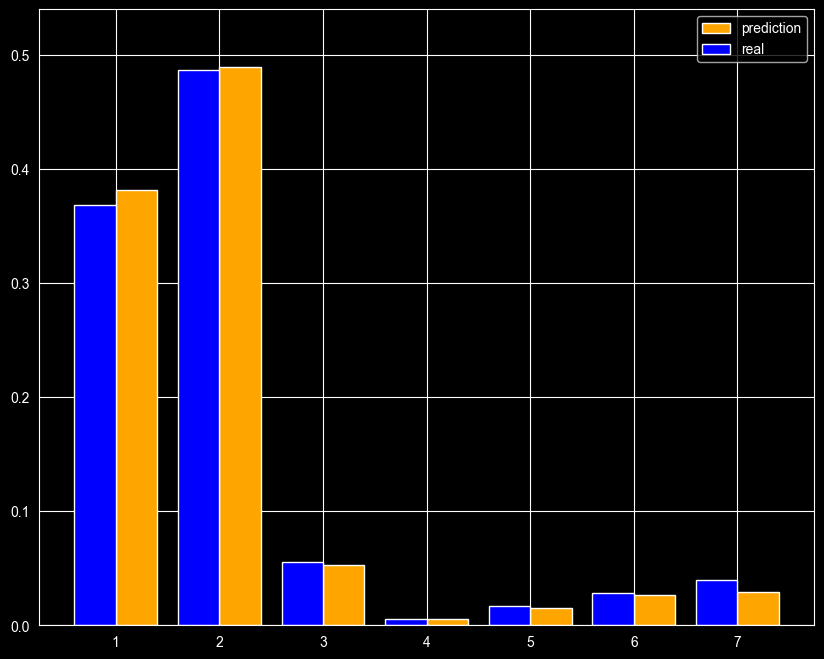

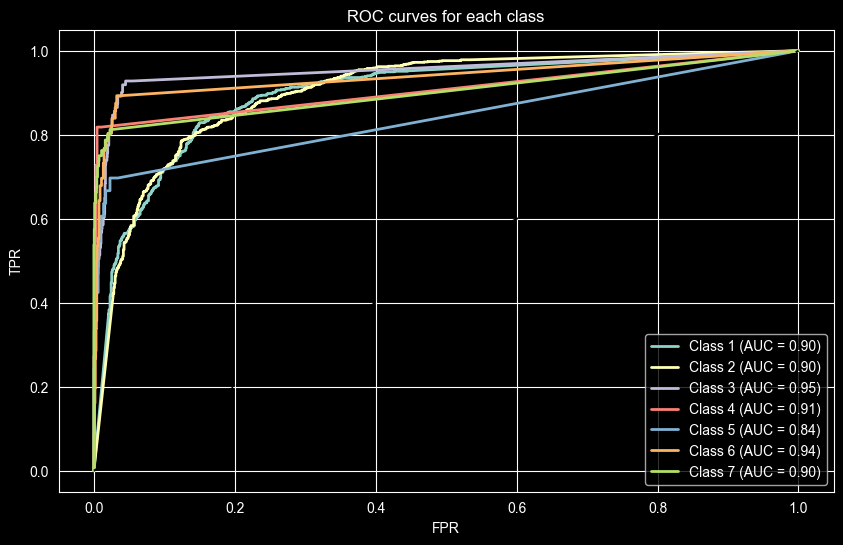

Mean ROC AUC across classes: 0.9057501676949595


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

all_data = pd.read_csv("/Users/ivankuznecov/Downloads/forest_dataset.csv")
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix,
    labels,
    test_size=0.2,
    random_state=42
)

clf = KNeighborsClassifier()

params = {
    "n_neighbors": range(1, 11),
    "metric": ["manhattan", "euclidean"],
    "weights": ["uniform", "distance"]}

clf_grid = GridSearchCV(clf, params, cv=5, scoring="accuracy", n_jobs=-1)
clf_grid.fit(X_train, y_train)
print(clf_grid.best_params_)

optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)
optimal_clf.fit(X_train, y_train)

pred_prob = optimal_clf.predict_proba(X_test)

unique, freq = np.unique(y_test, return_counts=True)
freq = list(map(lambda x: x / len(y_test), freq))
pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label="prediction", color="orange")
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label="real", color="blue")
plt.ylim(0, 0.54)
plt.legend()

y_pred = optimal_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Accuracy on test set:", acc)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6, 7])
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 6))
for i in range(7):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {i + 1} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curves for each class")
plt.legend()
plt.show()

print("Mean ROC AUC across classes:", np.mean(list(roc_auc.values())))